## Batch Normalization
A algorithm developed in 2015, which makes the training of NN faster and more stable (convergence in less epochs)

Abstract idea:
- It normalizes(mean=0, std=1) the activation vectors (vector of all activation) of hidden layers before passing them to next layer in the deep neural network


___Why Batch Normalization___:
1. We normalize the raw inputs to the neural network right? why that?   
Because if we do not normalize the inputs, they may have very different scale, which makes the loss space streched and hence large learning rates struggle to find minima and small learning rate makes the training slow.   
_Why not apply this normalization to outputs of each layer, since those outputs are inputs for further layers tooo..._


2. Internal Covariate Shift:
    - What is Covariate shift: covaraite shift is when statistical features of your input data (the 'covaraites') changes during either training or inference
        - For example: Below is an image where model is trained on red roses only but during prediction we gave it all color of roses, even though the decision boundary is same but that might not be sufficient and we may have to train model again on all types of roses

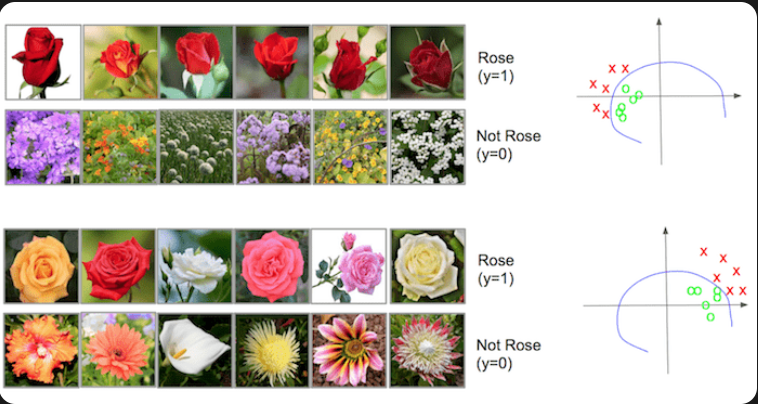

- Now, in Deep neural networks, similar thing happens. Consider the neural network below

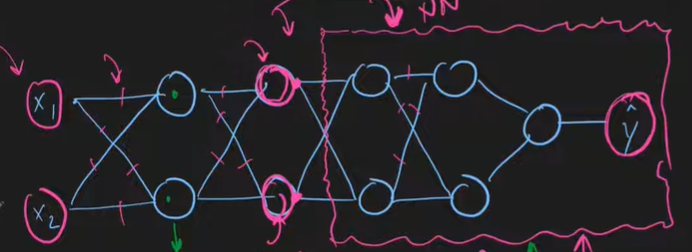

- If we assume that first half and second half of network as inidividual networks, The inputs to the second half are changing constantly during training because the weights of first half are changing (i.e outputs that are input to second half are also changing). Basically, the distribution of inputs to the second half of network is changing in each iteration. This is called __Internal Covariate Shift__

- To prevent this we normalize output vector of each layer using ___Batch Normalization___

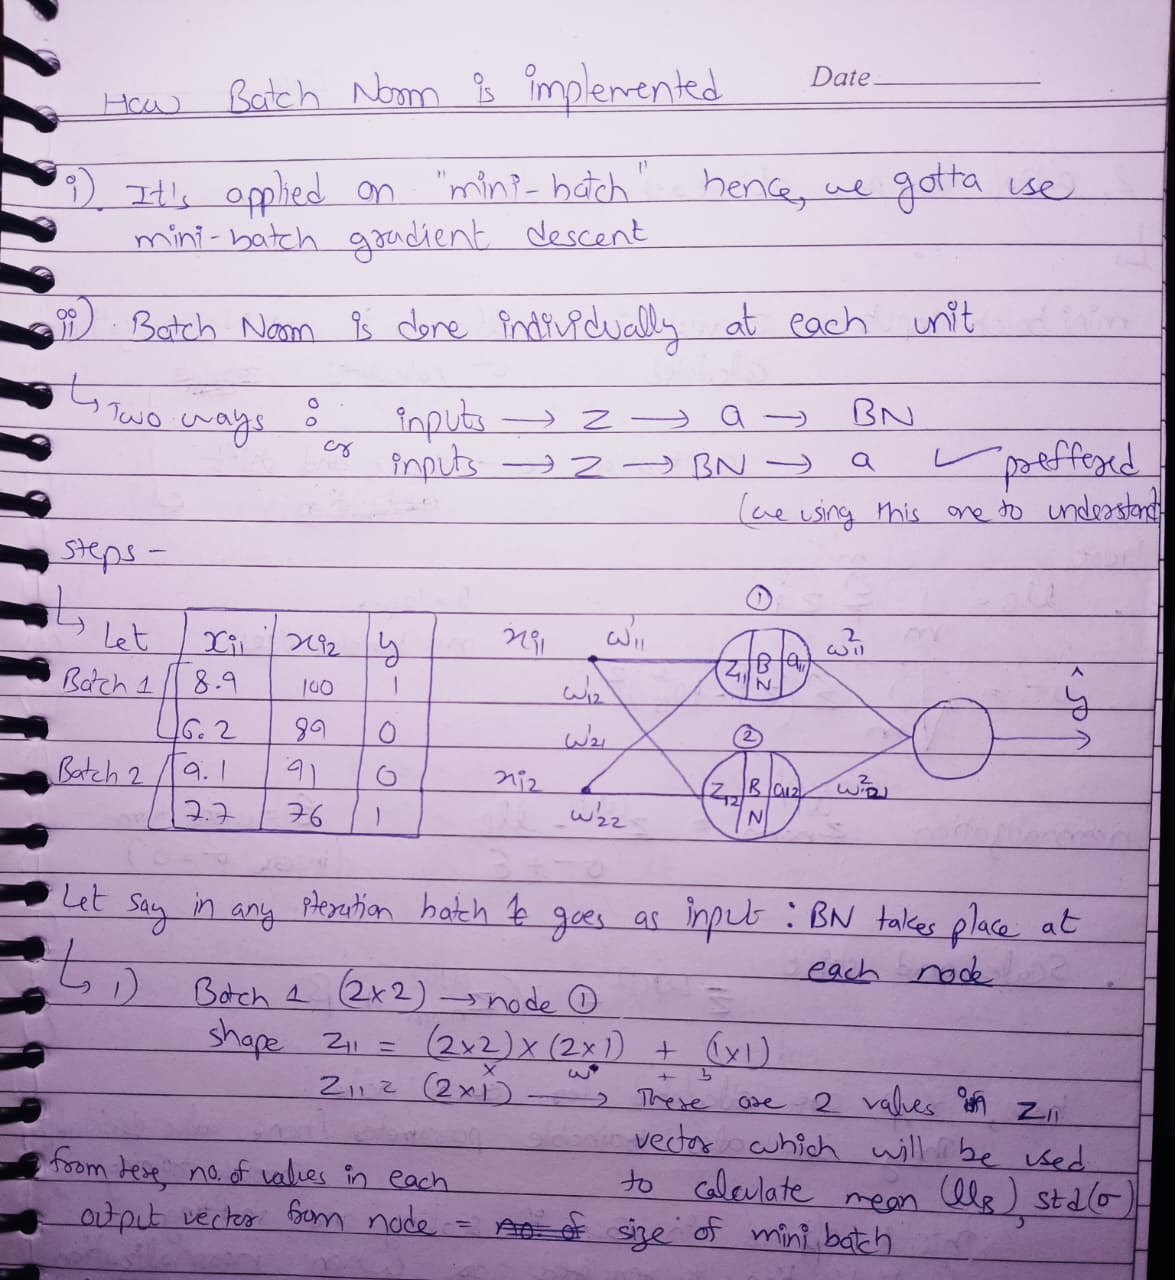

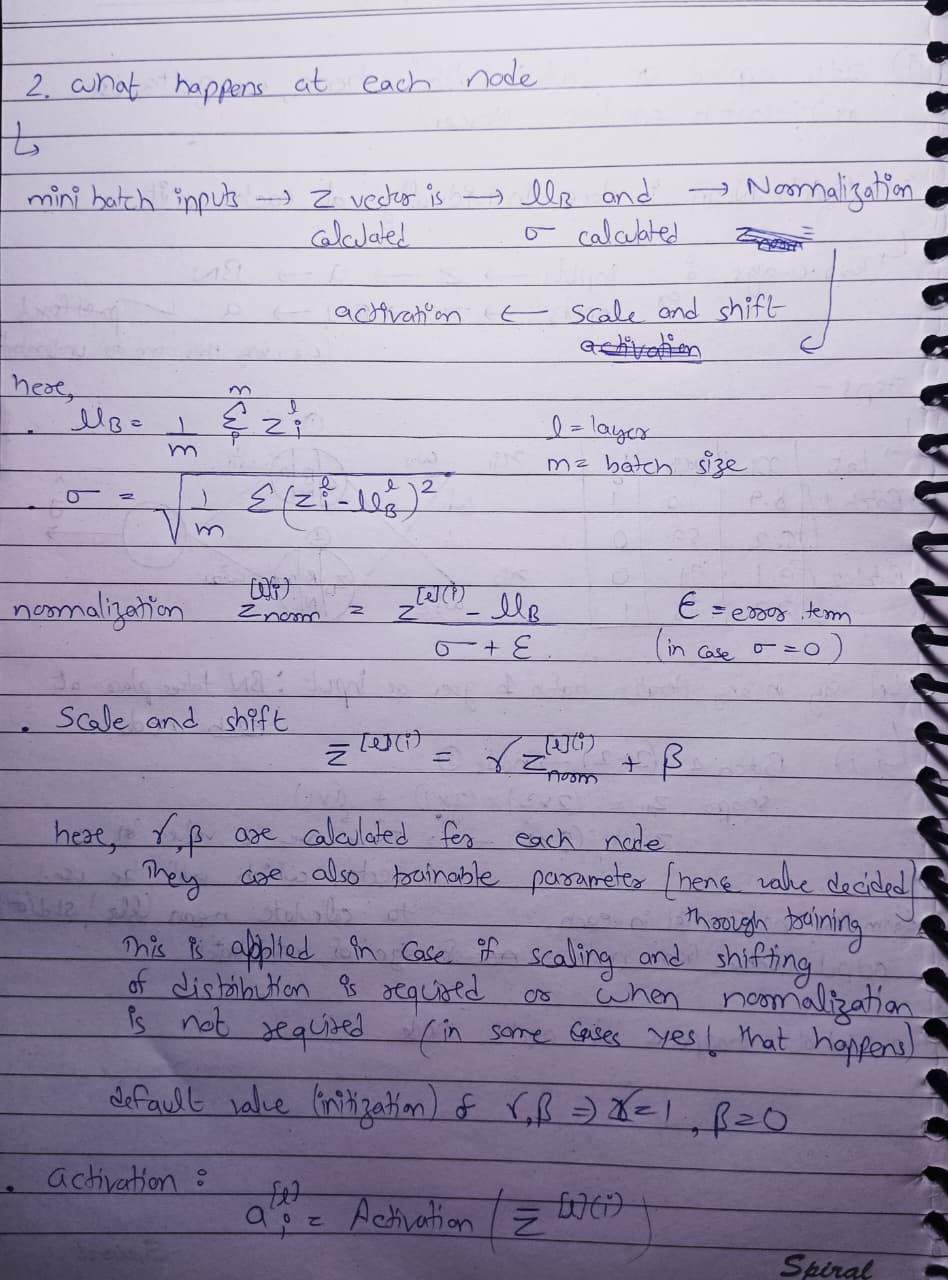

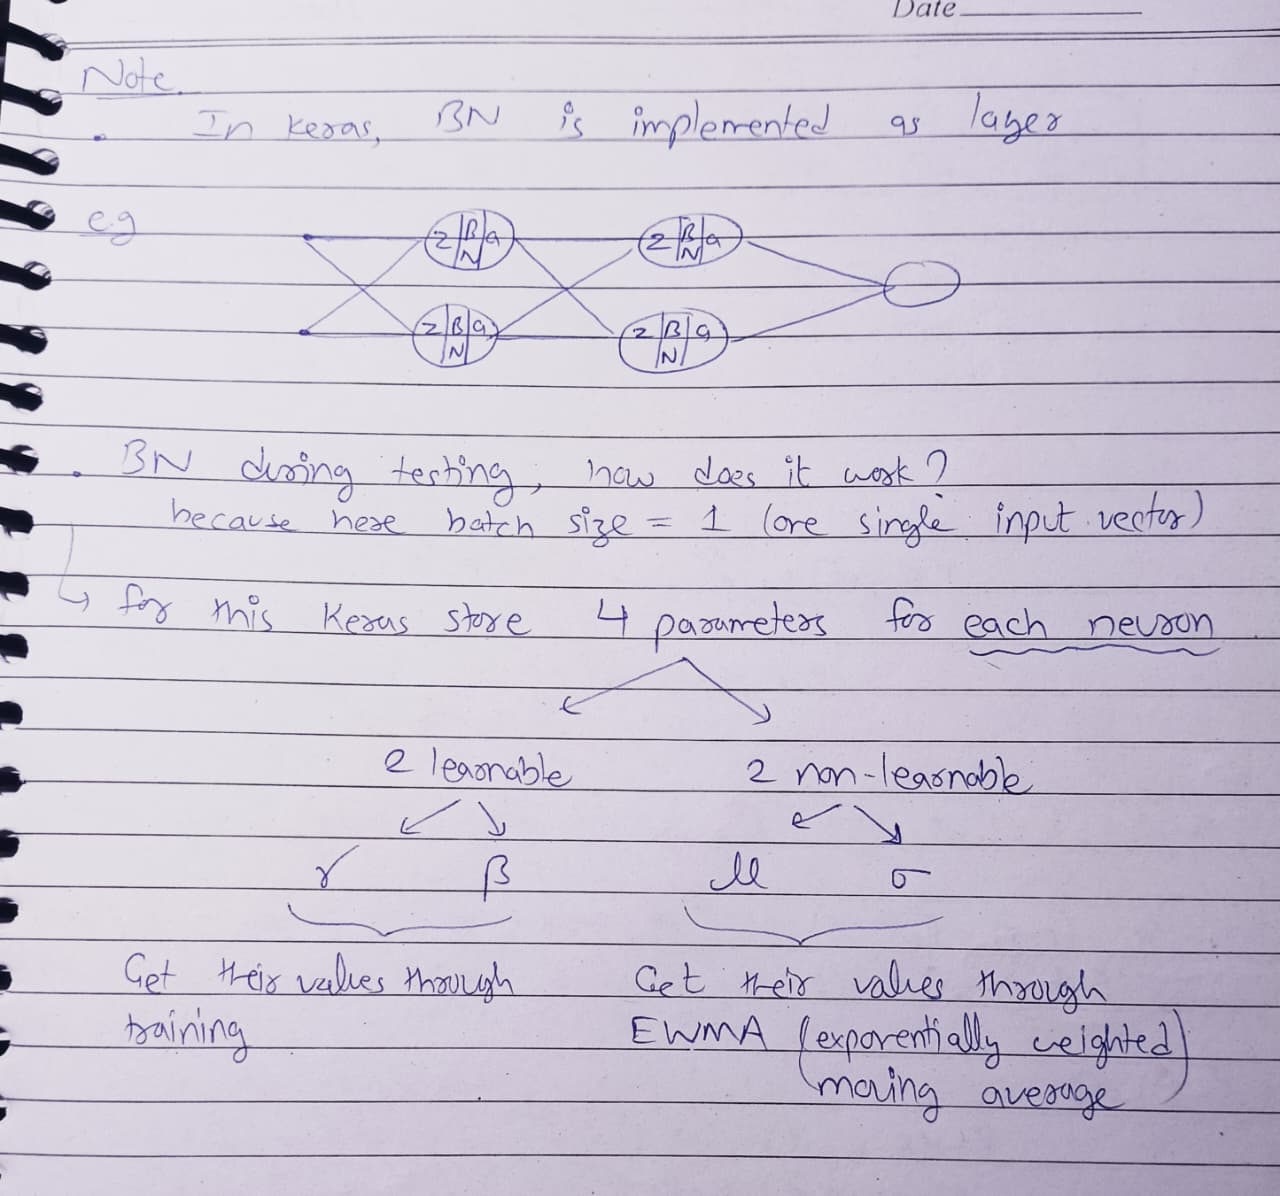

### Advantages
- Training becomes stable: wide range of hyperparameters can be chosen and it wont affect model much
- Training becomes faster: we can set large learning rate to make it faster and model still converges. 
- Reduces importance of perfect weight initialization: Since the weights space is not streched anymore, we can start out set of weights from anywhere and still land on minima
- Regularization: Not a strong regularizer, but still its one of the benefits we get from Batch Normalization because there is some randomness introduced while calculating $\gamma , \beta , \mu , \sigma $

In [9]:
from sklearn.datasets import make_circles
from keras.layers import Input, Dense, BatchNormalization
from keras import Sequential
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

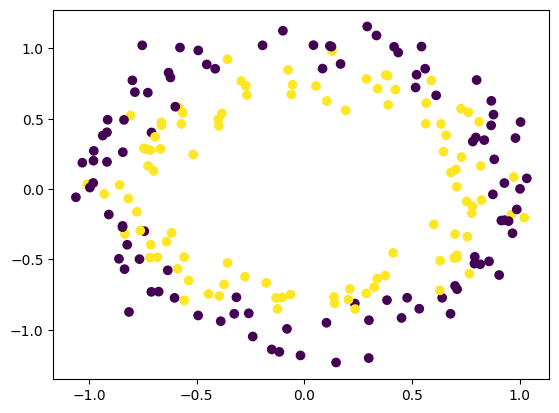

In [15]:
X,y = make_circles(200, noise=0.1)
plt.scatter(X[:,0],X[:,1],c=y)

In [16]:
# Implementation without batch normalization
model1 = Sequential()
model1.add(Input(shape=(X.shape[1],)))
model1.add(Dense(3,activation='relu', kernel_initializer='he_normal'))
model1.add(Dense(3,activation='relu',kernel_initializer='he_normal'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['Accuracy'])
history1 = model1.fit(X,y, batch_size=25, epochs=200, verbose=1, validation_split=0.2)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - Accuracy: 0.5125 - loss: 0.7178 - val_Accuracy: 0.4750 - val_loss: 0.7139
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Accuracy: 0.5125 - loss: 0.7163 - val_Accuracy: 0.4750 - val_loss: 0.7127
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Accuracy: 0.5188 - loss: 0.7152 - val_Accuracy: 0.4750 - val_loss: 0.7113
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Accuracy: 0.5125 - loss: 0.7142 - val_Accuracy: 0.4750 - val_loss: 0.7100
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - Accuracy: 0.5063 - loss: 0.7126 - val_Accuracy: 0.4750 - val_loss: 0.7092
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - Accuracy: 0.5000 - loss: 0.7118 - val_Accuracy: 0.4750 - val_loss: 0.7082
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Accuracy: 0.5125 - loss: 0.7109 - val_Accuracy: 0.4750 - val_loss: 0.7073
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.5125 - loss: 0.7100 - val_Accuracy: 0.4750 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 774us/step


<Axes: >

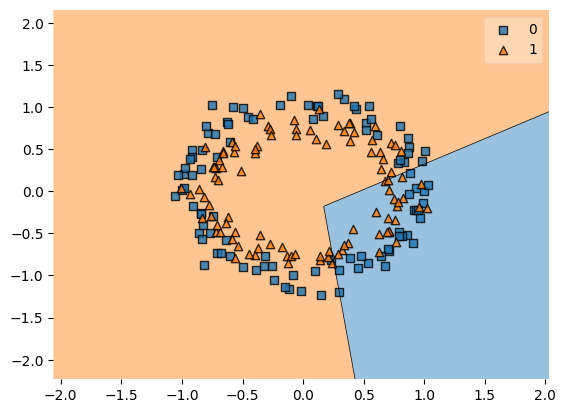

In [23]:
plot_decision_regions(X,y,model1)

In [18]:
# Implementation with batch normalization
model2 = Sequential()
model2.add(Input(shape=(X.shape[1],)))
model2.add(Dense(3,activation='relu', kernel_initializer='he_normal'))
model2.add(BatchNormalization())
model2.add(Dense(3,activation='relu',kernel_initializer='he_normal'))
model2.add(BatchNormalization())
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 12 (48.00 B)

In [19]:
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['Accuracy'])
history2 = model2.fit(X,y, batch_size=25, epochs=200, verbose=1, validation_split=0.2)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - Accuracy: 0.4750 - loss: 0.7543 - val_Accuracy: 0.5000 - val_loss: 0.7418
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - Accuracy: 0.4563 - loss: 0.7731 - val_Accuracy: 0.4750 - val_loss: 0.7320
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - Accuracy: 0.5125 - loss: 0.7576 - val_Accuracy: 0.4750 - val_loss: 0.7261
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.4875 - loss: 0.7452 - val_Accuracy: 0.4750 - val_loss: 0.7223
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.4938 - loss: 0.7540 - val_Accuracy: 0.5000 - val_loss: 0.7197
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.5063 - loss: 0.7351 - val_Accuracy: 0.5000 - val_loss: 0.7179
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - Accuracy: 0.5000 - loss: 0.7475 - val_Accuracy: 0.5000 - val_loss: 0.7165
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Accuracy: 0.4437 - loss: 0.7498 - val_Accuracy: 0.5000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 802us/step


<Axes: >

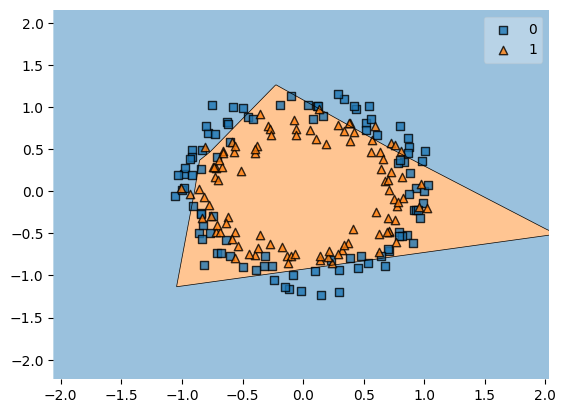

In [24]:
plot_decision_regions(X,y, model2)

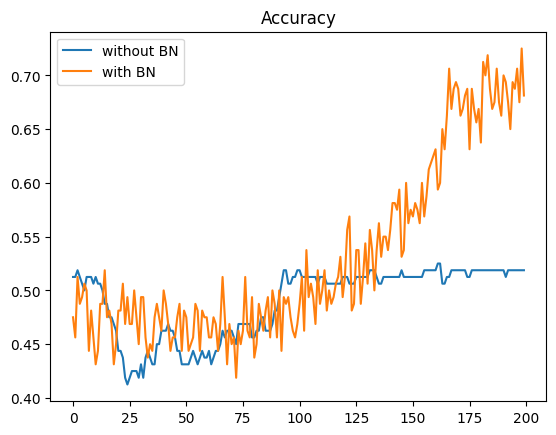

In [22]:
plt.plot(history1.history['Accuracy'],label='without BN')
plt.plot(history2.history['Accuracy'],label='with BN')
plt.legend()
plt.title("Accuracy")
plt.show()